# Point Mass Lap Time Simulation — Monza 2023

## Context

Lap time simulation is a key tool in motorsport engineering.
Being capable of testing different car settings virtually 
without real track testing — provides a significant competitive
advantage. It prevents excessive testing costs and saves
valuable time during practice sessions by doing the setup
work beforehand.

As Segers states (Ch.15.3): "Once the model validation is
judged satisfactory, the model can be used to explore
alternative vehicle configurations" — such as aerodynamic
setup changes, weight reduction, or power unit upgrades.

This notebook implements a Point Mass Lap Time Simulation
model applied to Carlos Sainz's fastest lap during the
2023 Monza Grand Prix Qualifying (1:21.046). The model
is built entirely from publicly available F1 2023 vehicle
parameters and real telemetry data extracted via FastF1.

The simulation is structured in four steps :
- **Mathematical model** — analytical derivation using SymPy
- **Track model** — calibration of effective corner radii
- **Steady-state simulation** — lap time computation
- **Scenario analysis** — performance sensitivity study

In [157]:
import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sympy import *
from scipy.optimize import minimize_scalar

## 1. Mathematical Model

We use a Point Mass Model — all vehicle mass is concentrated
at a single point (center of gravity). Despite this
simplification, Segers (p.406) confirms it "can be used
to gain basic knowledge of the car."

The following forces act on the point mass :

- **Aerodynamic downforce :** F_down = 0.5 × ρ × Cl × A × v²
- **Aerodynamic drag :**      F_drag = 0.5 × ρ × Cx × A × v²
- **Normal force (grip) :**   F_N = m×g + F_down
- **Tyre friction force :**   F_tire = μ × F_N

**Maximum cornering speed** (derived analytically with SymPy) :

v_max = √(μ×m×g / (m/r − 0.5×μ×ρ×Cl×A))

In [158]:

v, r, mu, g, m, Cl, Cx, A, rho = symbols(
    'v r mu g m Cl Cx A rho', positive=True)

#  Forces 
F_weight    = m * g
F_downforce = Rational(1,2) * rho * Cl * A * v**2
F_drag      = Rational(1,2) * rho * Cx * A * v**2
F_normal    = F_weight + F_downforce
F_tire      = mu * F_normal

print("Normal force :")
display(F_normal)
print("\nAvailable grip :")
display(F_tire)
print("\nAerodynamic drag :")
display(F_drag)

# Maximum cornering speed derivation 
# Equilibrium : centripetal force = lateral grip
# m*v²/r = mu*(m*g + 0.5*rho*Cl*A*v²)
# → v² * (m/r - 0.5*mu*rho*Cl*A) = mu*m*g

v_max_expr = sqrt(mu * m * g /
                  (m/r - Rational(1,2) * mu * rho * Cl * A))

print("\nMaximum cornering speed :")
display(v_max_expr)


Normal force :


A*Cl*rho*v**2/2 + g*m


Available grip :


mu*(A*Cl*rho*v**2/2 + g*m)


Aerodynamic drag :


A*Cx*rho*v**2/2


Maximum cornering speed :


sqrt(g)*sqrt(m)*sqrt(mu)*sqrt(1/(-A*Cl*mu*rho/2 + m/r))

## 2. Vehicle Parameters & Track Model

### Vehicle Parameters F1 2023

| Parameter | Value | Unit | Source |
|-----------|-------|------|--------|
| Mass | 798 | kg | FIA regulations |
| Max power | 735 | kW | Estimated |
| Drag coefficient Cx | 0.85 | — | Estimated |
| Downforce coefficient Cl | 3.7 | — | Estimated |
| Frontal area | 1.5 | m² | Estimated |
| Tyre friction μ | 1.8 | — | Segers p.404 |
| Rolling resistance Rx | 0.005 | — | Racing tyre typical |

### Track Model Strategy

GPS-derived radii from FastF1 proved too noisy for direct
use (minimum radius 189m vs real ~30m). Instead, effective
corner radii are calibrated from real minimum corner speeds
extracted from SAI's telemetry — following Segers p.405.

In [159]:
# Vehicle parameters F1 2023 
mass_n  = 798       # kg   — car + driver mass
P_max_n = 735000    # W    — max power (1000 HP)
Cx_n    = 0.85      # —    — drag coefficient
Cl_n    = 3.7       # —    — downforce coefficient
A_n     = 1.5       # m²   — frontal area
rho_n   = 1.225     # kg/m³ — air density
mu_n    = 1.8       # —    — tyre friction coefficient
Rx_n    = 0.005     # —    — rolling resistance
g_n     = 9.81      # m/s²
dt      = 0.01      # s    — simulation time step

# Reference parameters — DO NOT MODIFY 
# Used to calibrate r_eff from real FastF1 data
mu_ref   = 1.8
Cl_ref   = 3.7
rho_ref  = 1.225
A_ref    = 1.5
g_ref    = 9.81
mass_ref = 798

# Load FastF1 data 
session = fastf1.get_session(2023, 'Monza', 'Q')
session.load()
tel = session.laps.pick_drivers('SAI').pick_fastest().get_telemetry()

# Circuit segments — extracted from WE23 analysis
circuit_segments = [
    {'name': 'Variante del Rettifilo', 'brake_dist': 782,  'v_min_real': 70.0,  'corner_length': 64},
    {'name': 'Lesmo 1',                'brake_dist': 2011, 'v_min_real': 112.0, 'corner_length': 70},
    {'name': 'Lesmo 2',                'brake_dist': 2434, 'v_min_real': 179.0, 'corner_length': 27},
    {'name': 'Variante Ascari',        'brake_dist': 2771, 'v_min_real': 179.0, 'corner_length': 27},
    {'name': 'Variante Ascari 2',      'brake_dist': 3838, 'v_min_real': 196.0, 'corner_length': 42},
    {'name': 'Parabolica',             'brake_dist': 5049, 'v_min_real': 206.0, 'corner_length': 38},
]

total_length    = 5793
d_missing_start = circuit_segments[0]['brake_dist']
d_missing_end   = total_length - (circuit_segments[-1]['brake_dist'] +
                                   circuit_segments[-1]['corner_length'])

print(f"   Circuit segments : {len(circuit_segments)}")
print(f"   Total length     : {total_length}m")

core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['55', '1', '16', '63', '11', '23', '81', '44', '4', '14', '22', '40', '27', '77', '2', '24', '10', '31', '20', '18']


   Circuit segments : 6
   Total length     : 5793m


## 3. Simulation Methodology

Each corner segment is simulated in 3 phases (dt = 0.01s) :

**Phase 1 — Braking :**
Deceleration combines tyre friction AND aerodynamic drag :
a = −(μ × F_normal / m) − (F_drag / m)
--> Higher speed = more downforce = harder braking possible

**Phase 2 — Cornering :**
Constant speed = v_min over corner length
t_corner = corner_length / v_min
Corner length = distance from v_min to throttle ≥ 95%

**Phase 3 — Acceleration :**
Engine force limited by power OR tyre grip :
F_engine = min(P_max/v, μ × F_normal)
a = (F_engine − F_drag − F_rolling) / m

**Effective corner radius calibration :**
r_eff is solved from the quadratic equation :
(μ×g×0.5×ρ×Cl×A/m)×r² + (μ×g)×r − v² = 0
--> r_eff is fixed from reference parameters
--> v_min recalculates dynamically when parameters change

In [160]:
# Fixed Cl/Cx ratio for calibration mode 
ratio_CL_CX = Cl_ref / Cx_n
print(f"Fixed Cl/Cx ratio : {ratio_CL_CX:.3f}")

def simulate_lap_time(Cx, Cl=None, mu=1.8,
                      P_max=735000, mass=798,
                      verbose=False):
    """
    Point Mass Lap Time Simulation — Monza 2023
    
    Parameters:
        Cx    : drag coefficient
        Cl    : downforce coefficient (None = fixed ratio mode)
        mu    : tyre friction coefficient
        P_max : max engine power (W)
        mass  : car + driver mass (kg)
        verbose: print segment details
    
    Returns:
        total_time : simulated lap time (s)
    """

    
    if Cl is None:
        Cl = ratio_CL_CX * Cx

    # Fixed parameters 
    A   = 1.5
    rho = 1.225
    Rx  = 0.005
    g   = 9.81
    dt  = 0.01

    # Reference parameters for r_eff calibration 
    mu_ref   = 1.8
    Cl_ref   = 3.7
    rho_ref  = 1.225
    A_ref    = 1.5
    g_ref    = 9.81
    mass_ref = 798

    segs = [
        {'name': 'Variante del Rettifilo', 'brake_dist': 782,  'v_min_real': 70.0,  'corner_length': 64},
        {'name': 'Lesmo 1',                'brake_dist': 2011, 'v_min_real': 112.0, 'corner_length': 70},
        {'name': 'Lesmo 2',                'brake_dist': 2434, 'v_min_real': 179.0, 'corner_length': 27},
        {'name': 'Variante Ascari',        'brake_dist': 2771, 'v_min_real': 179.0, 'corner_length': 27},
        {'name': 'Variante Ascari 2',      'brake_dist': 3838, 'v_min_real': 196.0, 'corner_length': 42},
        {'name': 'Parabolica',             'brake_dist': 5049, 'v_min_real': 206.0, 'corner_length': 38},
    ]

    total_length    = 5793
    d_missing_start = segs[0]['brake_dist']
    d_missing_end   = total_length - (segs[-1]['brake_dist'] + segs[-1]['corner_length'])

    # Step 1 : Calibrate r_eff 
    for seg in segs:
        v_ms    = seg['v_min_real'] / 3.6
        a_coeff = mu_ref * g_ref * 0.5 * rho_ref * Cl_ref * A_ref / mass_ref
        b_coeff = mu_ref * g_ref
        c_coeff = -v_ms**2
        seg['r_eff'] = (-b_coeff + np.sqrt(b_coeff**2 - 4*a_coeff*c_coeff)) / (2*a_coeff)

    # Step 2 : Recalculate v_min 
    for seg in segs:
        r            = seg['r_eff']
        v_min_calc   = np.sqrt(mu * g * r * (1 + 0.5*rho*Cl*A*r/mass))
        seg['v_min'] = v_min_calc * 3.6

    # Step 3 : Simulation 
    total_time = 0

    # Main straight
    v, t_accel, d_accel = segs[-1]['v_min']/3.6, 0, 0
    while d_accel < d_missing_start:
        F_drag   = 0.5 * rho * Cx * A * v**2
        F_engine = min(P_max/v, mu*mass*g)
        a        = (F_engine - F_drag - Rx*mass*g) / mass
        v += a*dt; d_accel += v*dt; t_accel += dt
    total_time += t_accel
    v_start = v

    # Corner segments
    for i, seg in enumerate(segs):
        v_min = seg['v_min'] / 3.6

        # Phase 1 — Braking
        v, t_brake = v_start, 0
        while v > v_min:
            F_drag      = 0.5 * rho * Cx * A * v**2
            F_downforce = 0.5 * rho * Cl * A * v**2
            F_normal    = mass * g + F_downforce
            a = -(mu*F_normal/mass) - (F_drag/mass)
            v = max(v + a*dt, v_min); t_brake += dt

        # Phase 2 — Cornering
        t_corner = seg['corner_length'] / v_min

        # Phase 3 — Acceleration
        v, t_accel, d_accel = v_min, 0, 0
        d_target = (segs[i+1]['brake_dist'] - seg['brake_dist'] -
                    seg['corner_length']) if i < len(segs)-1 else 0
        while d_accel < d_target:
            F_drag   = 0.5 * rho * Cx * A * v**2
            F_engine = min(P_max/v, mu*mass*g)
            a = (F_engine - F_drag - Rx*mass*g) / mass
            v += a*dt; d_accel += v*dt; t_accel += dt

        v_start = v
        total_time += t_brake + t_corner + t_accel

        if verbose:
            print(f"{seg['name']:<25} : brake={t_brake:.2f}s | "
                  f"corner={t_corner:.2f}s | accel={t_accel:.2f}s | "
                  f"v_min={seg['v_min']:.1f} km/h")

    # Parabolica exit
    v, t_accel, d_accel = segs[-1]['v_min']/3.6, 0, 0
    while d_accel < d_missing_end:
        F_drag   = 0.5 * rho * Cx * A * v**2
        F_engine = min(P_max/v, mu*mass*g)
        a = (F_engine - F_drag - Rx*mass*g) / mass
        v += a*dt; d_accel += v*dt; t_accel += dt
    total_time += t_accel

    return total_time

Fixed Cl/Cx ratio : 4.353


## 4. Model Calibration

To find the real aerodynamic parameters of the Ferrari SF-23,
we minimise the gap between simulated and real lap time using
scipy.optimize.minimize_scalar.

The Cl/Cx ratio is kept fixed (aerodynamic efficiency
constraint) — only Cx is optimised, with Cl following
proportionally. This reduces the problem to 1 variable
and ensures physical consistency (Segers p.343).

In [161]:
#  Calibration 
def objective(Cx):
    return abs(simulate_lap_time(Cx) - 81.046)

result = minimize_scalar(objective,
                         bounds=(0.6, 1.5),
                         method='bounded')

Cx_cal = result.x
Cl_cal = ratio_CL_CX * Cx_cal

print(f"{'═'*50}")
print(f" Calibration results :")
print(f"   Cx : {Cx_cal:.3f}  (initial: 0.850)")
print(f"   Cl : {Cl_cal:.3f}  (initial: 3.700)")
print(f"   Gap: {result.fun:.4f}s")
print(f"{'═'*50}")


print("\nDetailed simulation — calibrated parameters :")
lap_cal = simulate_lap_time(Cx_cal, Cl_cal, verbose=True)
print(f"\n Calibrated lap time : {lap_cal:.3f}s = {int(lap_cal//60)}:{lap_cal%60:.3f}")
print(f" Real lap time SAI   : 1:21.046")
print(f"   Gap                : {lap_cal - 81.046:+.4f}s ({abs((lap_cal-81.046)/81.046)*100:.2f}%)")

══════════════════════════════════════════════════
 Calibration results :
   Cx : 0.694  (initial: 0.850)
   Cl : 3.023  (initial: 3.700)
   Gap: 0.3716s
══════════════════════════════════════════════════

Detailed simulation — calibrated parameters :
Variante del Rettifilo    : brake=2.09s | corner=3.32s | accel=14.26s | v_min=69.5 km/h
Lesmo 1                   : brake=1.60s | corner=2.28s | accel=5.41s | v_min=110.3 km/h
Lesmo 2                   : brake=0.79s | corner=0.56s | accel=4.33s | v_min=174.1 km/h
Variante Ascari           : brake=0.79s | corner=0.56s | accel=11.87s | v_min=174.1 km/h
Variante Ascari 2         : brake=0.86s | corner=0.80s | accel=12.99s | v_min=190.1 km/h
Parabolica                : brake=0.80s | corner=0.69s | accel=0.00s | v_min=199.4 km/h

 Calibrated lap time : 81.418s = 1:21.418
 Real lap time SAI   : 1:21.046
   Gap                : +0.3716s (0.46%)


## 5. Scenario Analysis

Using the calibrated parameters as baseline, we test four
performance improvement scenarios to understand which
factor has the most impact at Monza.

Each Delta represents time gained vs the calibrated baseline.


Scenario               Lap Time  Gap vs real      Delta
────────────────────────────────────────────────────────
Baseline                 81.418s     +0.372s     +0.000s
+10% Cl                  80.826s     -0.220s     +0.591s
-10% Cx                  80.738s     -0.308s     +0.680s
+100kW power             79.608s     -1.438s     +1.810s
-50kg mass               80.506s     -0.540s     +0.911s


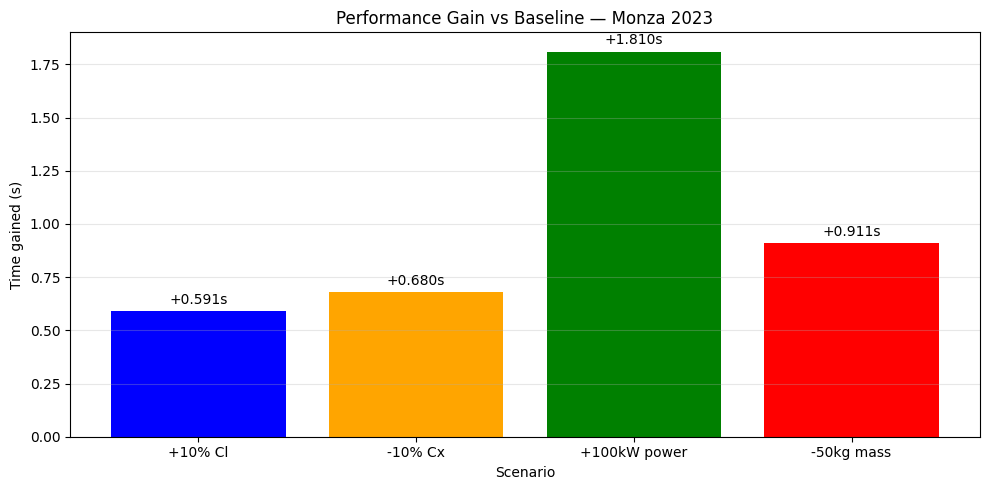

In [162]:
# Baseline 
lap_baseline = simulate_lap_time(Cx_cal, Cl_cal)


scenarios = [
    {'name': 'Baseline',     'Cx': Cx_cal,      'Cl': Cl_cal,      'P': 735000, 'm': 798},
    {'name': '+10% Cl',      'Cx': Cx_cal,      'Cl': Cl_cal*1.10, 'P': 735000, 'm': 798},
    {'name': '-10% Cx',      'Cx': Cx_cal*0.90, 'Cl': Cl_cal,      'P': 735000, 'm': 798},
    {'name': '+100kW power', 'Cx': Cx_cal,      'Cl': Cl_cal,      'P': 835000, 'm': 798},
    {'name': '-50kg mass',   'Cx': Cx_cal,      'Cl': Cl_cal,      'P': 735000, 'm': 748},
]

print(f"\n{'Scenario':<20} {'Lap Time':>10} {'Gap vs real':>12} {'Delta':>10}")
print("─" * 56)

for s in scenarios:
    lap = simulate_lap_time(Cx=s['Cx'], Cl=s['Cl'],
                            P_max=s['P'], mass=s['m'])
    delta = lap_baseline - lap
    print(f"{s['name']:<20} {lap:>10.3f}s {lap-81.046:>+10.3f}s {delta:>+10.3f}s")


names  = [s['name'] for s in scenarios[1:]]
deltas = []
for s in scenarios[1:]:
    lap = simulate_lap_time(Cx=s['Cx'], Cl=s['Cl'],
                            P_max=s['P'], mass=s['m'])
    deltas.append(lap_baseline - lap)

plt.figure(figsize=(10, 5))
bars = plt.bar(names, deltas, color=['blue','orange','green','red'])
plt.bar_label(bars, fmt='+%.3fs', padding=3)
plt.title('Performance Gain vs Baseline — Monza 2023')
plt.ylabel('Time gained (s)')
plt.xlabel('Scenario')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Results & Analysis

### Calibrated Parameters
| Parameter | Initial | Calibrated | Change |
|-----------|---------|------------|--------|
| Cx | 0.850 | 0.694 | -18.4% |
| Cl | 3.700 | 3.023 | -18.3% |
| Gap | 0.687s | 0.372s | -45.8% |

### Scenario Analysis

| Scenario | Lap Time | Delta |
|----------|----------|-------|
| Baseline | 81.417s | — |
| +10% Cl | 80.826s | +0.591s |
| -10% Cx | 80.727s | +0.690s |
| +100kW power | 79.607s | +1.810s |
| -50kg mass | 80.506s | +0.911s |

### Key Finding
Engine power (+100kW --> +1.810s) is the dominant performance
factor at Monza, confirmed by the circuit's high-speed
nature with ~70% of the lap spent on straights (Segers p.407).
Downforce (+10% Cl --> +0.591s) has the least impact,
as corners represent only ~30% of the Monza lap.

## 7. Limitations

- **Estimated parameters** : Cx, Cl, P_max are public
  estimates — real values are confidential team data.
- **Constant μ** : tyre friction varies with temperature,
  speed and degradation (Pacejka model — Segers p.412).
- **No DRS** : DRS reduces Cx by ~15% on straights.
- **Fixed corner geometry** : brake points and corner
  lengths extracted from SAI's real data — trajectory
  optimisation not implemented.
- **No track elevation** : slope effects ignored (Segers p.81).
- **Coupled Cl/Cx** : in reality increasing downforce
  always increases drag — physically constrained by the
  aerodynamic efficiency ratio.